# Generating data for our TDNIRS

From Patterson et al. we have the standard equation of:

$$ \Phi(\rho, t) = \frac{1}{(4 \pi D t)^{3/2}} \exp\left( -\frac{\rho^2}{4 D t} \right) \exp\left( -\mu_a c t \right) $$

I have simplified it such that it is easier to calculate a training set for my project, to do so I collapsed the complex physical constants into a generalized exponential decay model:

$$ y(t) = Ae^{-kt} $$

Where A is set to 10 and k to 5.

Where A (amplitude) represents inital intensity and k is the decay rate (product of mu and speed of light)

The goal of this project is to demonstrate a network's ability to recover a smooth signal from Poisson-distributed noise. Using a simplified model allows for the model to focus on the 'smoothness' of the data rather than computing the whole diffusion equation each training sample.

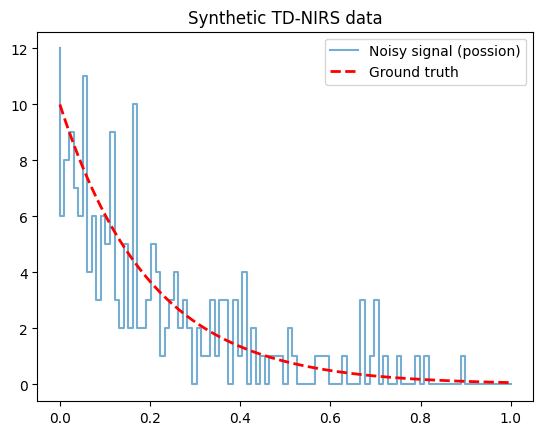

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
t = np.linspace(0, 1, 100)

# Mimic exponentional decay
true_signal = 10 * np.exp(-5*t)

noisy_signal = np.random.poisson(true_signal)

t_torch = torch.tensor(t, dtype=torch.float32).view(-1, 1)
noisy_torch = torch.tensor(noisy_signal, dtype=torch.float32).view(-1, 1)
true_torch = torch.tensor(noisy_signal, dtype=torch.float32).view(-1, 1)

plt.step(t, noisy_signal, label='Noisy signal (possion)', alpha=0.6)
plt.plot(t, true_signal, 'r--', label='Ground truth', linewidth=2)
plt.legend()
plt.title("Synthetic TD-NIRS data")
plt.show()

# Nueral Network Arcitecture

A multi layer perceptron (MLP) consisting of 3 linear layers and 2 relu functions.

The network takes an input, time and maps it to an output, intensity. By using hidden layers of 32 nuerons we allow it to learn the non linear shape of the curve.

We use RELU to prevent the vanishing gradient issue, aswell as it is more computationally effecient for a NN to learn non negative results via RELU.

For our standard black box loss function, we use a PINN.

MSE calculates how far the models perception is from noisy poisson dots.
I've also implemented a non negativity penalty, implemented as torch.relu(-outputs), if the model predicts a negative intensity
$$x$$
the penalty is:
$$x^2$$
If the model predicts a positive intensity the penalty is 0.

In [15]:
class DenoisingNet(nn.Module):
  def __init__(self):
    super(DenoisingNet, self).__init__()

    self.net = nn.Sequential(
        nn.Linear(1, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.net(x)

def physicsInformedLoss(outputs, targets):
  mse_loss = nn.MSELoss()(outputs, targets)
  physics_violation = torch.relu(-outputs)
  non_negativity_penalty = torch.mean(physics_violation**2)
  return mse_loss + (10 * non_negativity_penalty)

model = DenoisingNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Epoch: 0, Loss: 12.8085
Epoch: 200, Loss: 1.9050
Epoch: 400, Loss: 1.9006
Epoch: 600, Loss: 1.8999
Epoch: 800, Loss: 1.8990


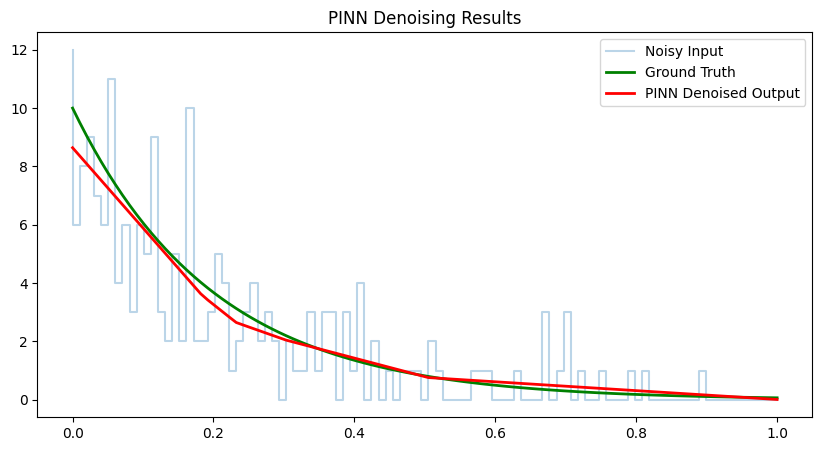

In [16]:
epochs = 1000
for epoch in range(epochs):
  optimizer.zero_grad()
  predictions = model(t_torch)
  loss = physicsInformedLoss(predictions, noisy_torch)
  loss.backward()
  optimizer.step()

  if epoch % 200 == 0:
    print(f"Epoch: {epoch}, Loss: {loss.item():.4f}")

with torch.no_grad():
  denoised_signal = model(t_torch).numpy()

plt.figure(figsize=(10,5))
plt.step(t, noisy_signal, label='Noisy Input', alpha=0.3)
plt.plot(t, true_signal, 'g-', label='Ground Truth', linewidth=2)
plt.plot(t, denoised_signal, 'r-', label='PINN Denoised Output', linewidth=2)
plt.legend()
plt.title("PINN Denoising Results")
plt.show()

In [17]:
def generate_tdnirs_batch(num_samples=1000):
    t = np.linspace(0, 1, 100)

    clean_batch = np.zeros((num_samples, 100))
    noisy_batch = np.zeros((num_samples, 100))

    for i in range(num_samples):
        A = np.random.uniform(5, 20)
        k = np.random.uniform(2, 8)

        true_curve = A * np.exp(-k * t)

        noisy_curve = np.random.poisson(true_curve)

        clean_batch[i] = true_curve
        noisy_batch[i] = noisy_curve

    return torch.from_numpy(noisy_batch).float(), torch.from_numpy(clean_batch).float()

train_input, train_target = generate_tdnirs_batch(2000)

print(f"Dataset Created efficiently!")
print(f"Input Shape: {train_input.shape}")

Dataset Created efficiently!
Input Shape: torch.Size([2000, 100])


# Input Layer Expansion

Instead of seeing one time point at a time, the model now sees the entire context. This allows the network to recognize the "shape" of the decay. If one point is an outlier, the model can look at the neighboring points to "know" that the point should actually be lower.

(Also made middle layer wider giving model more opportunities to learn any combination of A and k)

In [18]:
class SignalDenoiser(nn.Module):
    def __init__(self):
        super(SignalDenoiser, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 100)
        )

    def forward(self, x):
        return self.net(x)

p2_model = SignalDenoiser()
p2_optimizer = optim.Adam(p2_model.parameters(), lr=0.001)

# Training new model on whole curves rather than individual nodes

In [19]:
epochs_p2 = 500
batch_size = 32

for epoch in range(epochs_p2):
    permutation = torch.randperm(train_input.size(0))

    epoch_loss = 0
    for i in range(0, train_input.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = train_input[indices], train_target[indices]

        p2_optimizer.zero_grad()
        outputs = p2_model(batch_x)

        loss = physicsInformedLoss(outputs, batch_y)

        loss.backward()
        p2_optimizer.step()
        epoch_loss += loss.item()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Average Loss: {epoch_loss / (2000/batch_size):.4f}")

Epoch 0 | Average Loss: 4.2821
Epoch 50 | Average Loss: 0.0528
Epoch 100 | Average Loss: 0.0170
Epoch 150 | Average Loss: 0.0120
Epoch 200 | Average Loss: 0.0050
Epoch 250 | Average Loss: 0.0034
Epoch 300 | Average Loss: 0.0114
Epoch 350 | Average Loss: 0.0026
Epoch 400 | Average Loss: 0.0025
Epoch 450 | Average Loss: 0.0022


# Random test

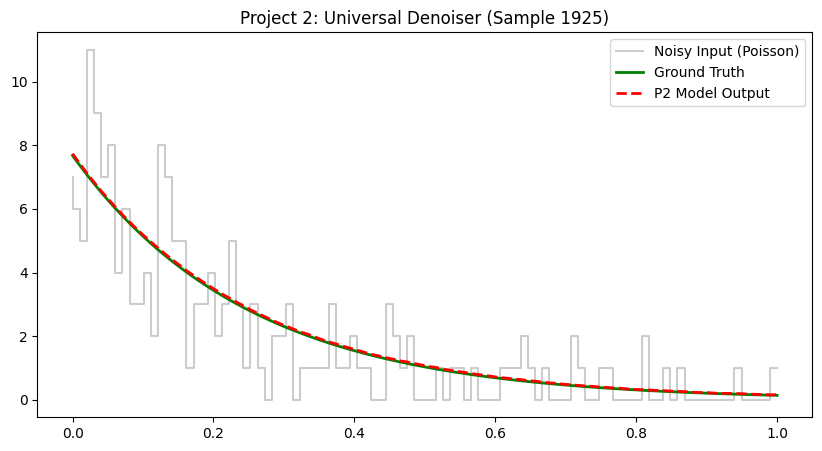

In [20]:
sample_idx = np.random.randint(0, 2000)
test_input = train_input[sample_idx].unsqueeze(0)
test_target = train_target[sample_idx]

p2_model.eval()
with torch.no_grad():
    denoised_signal = p2_model(test_input).squeeze().numpy()

plt.figure(figsize=(10, 5))
plt.step(t, train_input[sample_idx].numpy(), label='Noisy Input (Poisson)', color='gray', alpha=0.4)
plt.plot(t, test_target.numpy(), 'g-', label='Ground Truth', linewidth=2)
plt.plot(t, denoised_signal, 'r--', label='P2 Model Output', linewidth=2)
plt.title(f"Project 2: Universal Denoiser (Sample {sample_idx})")
plt.legend()
plt.show()

To further improve the ground truth accuracy, the current simplified exponential decay model
$$ Ae^{-kt} $$
 can be replaced with forward-simulated data from NIRFAST. This would allow the model to learn from complex 3D tissue geometries while maintaining the Poisson noise and PINN-loss frameworks developed in this project.